# Phase 1 - Data Layer

Builds a **clean daily feature panel** for the regime framework, starting with **CL (WTI)**.

What this notebook produces (cached to `cache/`):
- Daily curve snapshot (last 1-min obs per UTC day) for `c1..cN` weighted-mid.
- **Target structure:** `c1-c2` calendar spread.
- **Volatility feature:** realized vol of `c1` from intraday 1-min log returns.
- **Curve features:** slope (`c1-c2`), and PCA level/slope/curvature (PCA fit on TRAIN only -> no lookahead).
- **Seasonal features:** month `sin/cos`, day-of-year, approx days-to-expiry of the front contract.
- **Fundamentals (optional):** EIA / FRED / yfinance, point-in-time aligned. Skipped gracefully if keys/internet absent.
- **Train/test split** at `2026-03-01` (test = trailing months; data ends 2026-05-22).

Design reference: regimes classified daily; 1-min data only used to compute features.

In [1]:
import os, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

# ---- config ----
DATA_DIR  = Path("../data")
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)
INSTRUMENT = "CL"                       # focus instrument for Phase 1
DATA_FILE  = DATA_DIR / f"{INSTRUMENT}_data.csv"
DEPTH      = 12                         # curve depth used for PCA features
TEST_START = pd.Timestamp("2026-03-01")  # everything >= this date is test
print("data file:", DATA_FILE, "exists:", DATA_FILE.exists())

data file: ..\data\CL_data.csv exists: True


## 1. Load the 1-min curve
Read only `timestamp`, every `cN||weighted_mid`, and the front two contract symbols. The first line of the file is a `#meta` comment, so we skip it.

In [2]:
def load_curve(path, depth=DEPTH):
    wm_cols   = [f"c{i}||weighted_mid" for i in range(1, depth+1)]
    con_cols  = ["c1||contract", "c2||contract"]
    keep      = set(["timestamp"] + wm_cols + con_cols)
    df = pd.read_csv(
        path, skiprows=1,                       # skip the #meta line
        usecols=lambda c: c in keep,
        parse_dates=["timestamp"],
    )
    df = df.sort_values("timestamp").set_index("timestamp")
    return df

raw = load_curve(DATA_FILE)
print("rows:", f"{len(raw):,}", "| span:", raw.index.min(), "->", raw.index.max())
raw.head(3)

rows: 1,831,283 | span: 2021-01-04 01:00:00+00:00 -> 2026-05-22 14:59:00+00:00


,c1||contract,c1||weighted_mid,c2||contract,c2||weighted_mid,c3||weighted_mid,c4||weighted_mid,c5||weighted_mid,c6||weighted_mid,c7||weighted_mid,c8||weighted_mid,c9||weighted_mid,c10||weighted_mid,c11||weighted_mid,c12||weighted_mid
timestamp,,,,,,,,,,,,,,
2021-01-04 01:00:00+00:00,CLG1,48.424000,CLH1,48.609924,48.454,48.63,48.08381,47.996667,48.5,46.937097,48.105,NaN,47.61,40.713077
2021-01-04 03:04:00+00:00,CLG1,48.413333,CLH1,48.609924,48.454,48.63,48.08381,47.996667,48.5,46.937097,48.105,NaN,47.61,40.713077
2021-01-04 03:06:00+00:00,CLG1,48.406667,CLH1,48.609924,48.454,48.63,48.08381,47.996667,48.5,46.937097,48.105,NaN,47.61,40.713077


## 2. Resample to a daily panel
For each UTC day we take the **last** non-null observation of each column (a settle-like snapshot) and the number of 1-min obs that day. Realized vol is computed from the full intraday `c1` series.

In [3]:
wm_cols = [f"c{i}||weighted_mid" for i in range(1, DEPTH+1)]
day = raw.index.normalize()

# last obs per day for each weighted-mid + front contract symbols
daily = raw.groupby(day).last()
daily["n_obs"] = raw.groupby(day).size()
daily.index.name = "date"

# realized vol of c1 from intraday 1-min log returns
c1 = raw["c1||weighted_mid"].astype(float)
logret = np.log(c1).diff()
rv = logret.groupby(raw.index.normalize()).std()      # daily std of 1-min log returns
daily["rv_c1"] = rv
daily["rv_c1_ann"] = daily["rv_c1"] * np.sqrt(252 * 1440)   # annualized (informational)

print("daily rows:", len(daily))
daily[["c1||weighted_mid","c2||weighted_mid","n_obs","rv_c1"]].tail(3)

daily.index = daily.index.tz_localize(None)  # UTC wall-time -> naive for clean date math

daily rows: 1747


## 3. Structure, curve & seasonal features

In [4]:
f = pd.DataFrame(index=daily.index)

# --- target structure: front calendar spread ---
f["c1"] = daily["c1||weighted_mid"].astype(float)
f["c2"] = daily["c2||weighted_mid"].astype(float)
f["cal_1_2"] = f["c1"] - f["c2"]            # >0 backwardation, <0 contango for WTI

# --- volatility feature ---
f["rv_c1"] = daily["rv_c1"]

# --- curve slope (also used for the curve regime axis later) ---
f["slope_1_2"] = f["cal_1_2"]
f["slope_pct"] = (f["c1"] - f["c2"]) / f["c2"]

# --- PCA level/slope/curvature on the curve (fit on TRAIN only) ---
curve = daily[wm_cols].astype(float)
curve_full = curve.dropna()                 # need full curve for clean PCA
train_mask = curve_full.index < TEST_START
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(curve_full[train_mask])
pca = PCA(n_components=3).fit(scaler.transform(curve_full[train_mask]))
comps = pca.transform(scaler.transform(curve_full))
pcdf = pd.DataFrame(comps, index=curve_full.index,
                    columns=["pc_level","pc_slope","pc_curve"])
f = f.join(pcdf)
print("PCA explained var (train):", np.round(pca.explained_variance_ratio_, 3))

# --- seasonal features ---
doy = f.index.dayofyear
f["seas_sin"] = np.sin(2*np.pi*doy/365.25)
f["seas_cos"] = np.cos(2*np.pi*doy/365.25)
f["month"] = f.index.month

# --- approx days-to-expiry of front contract ---
MONTH_CODE = dict(zip("FGHJKMNQUVXZ", range(1,13)))
def front_expiry(sym):
    if not isinstance(sym, str): return np.nan
    m = re.match(r"^[A-Z]{2}([FGHJKMNQUVXZ])(\d{1,2})$", sym)
    if not m: return np.nan
    mon = MONTH_CODE[m.group(1)]; yr = int(m.group(2))
    yr = 2000+yr if yr >= 10 else 2020+yr
    # WTI expires ~20th of the month BEFORE the delivery month (approx)
    deliv = pd.Timestamp(year=yr, month=mon, day=1)
    exp = deliv - pd.Timedelta(days=11)
    return exp
exp = daily["c1||contract"].map(front_expiry)
f["front_contract"] = daily["c1||contract"]
f["days_to_expiry"] = (exp - f.index.to_series()).dt.days

f.tail(3)

PCA explained var (train): [0.978 0.008 0.003]


,c1,c2,cal_1_2,rv_c1,slope_1_2,slope_pct,pc_level,pc_slope,pc_curve,seas_sin,seas_cos,month,front_contract,days_to_expiry
date,,,,,,,,,,,,,,
2026-05-20,98.532500,94.330000,4.202500,0.001664,4.202500,0.044551,3.156915,1.215165,0.047675,0.669290,-0.743001,5,CLN26,31
2026-05-21,97.377500,94.126667,3.250833,0.001225,3.250833,0.034537,3.168827,1.172842,0.047330,0.656411,-0.754404,5,CLN26,30
2026-05-22,98.303333,94.956667,3.346667,0.000702,3.346667,0.035244,3.454497,1.131478,0.045055,0.643337,-0.765584,5,CLN26,29


## 4. Fundamentals (EIA / FRED / yfinance) - point-in-time, optional
These run only if keys are in `.env` and there is internet. Each source is wrapped so a failure just prints a notice and the panel still builds from curve features.

In [5]:
from dotenv import load_dotenv
load_dotenv()
EIA_KEY  = os.getenv("EIA_API_KEY") or ""
FRED_KEY = os.getenv("FRED_API_KEY") or ""

fund = pd.DataFrame(index=f.index)

# ---- yfinance: non-revised market state (no key needed) ----
try:
    import yfinance as yf
    yq = yf.download(["^VIX","DX-Y.NYB","^GSPC"], start="2020-12-01",
                     progress=False)["Close"]
    yq = yq.rename(columns={"^VIX":"vix","DX-Y.NYB":"dxy","^GSPC":"spx"})
    yq.index = pd.to_datetime(yq.index).tz_localize(None)
    fund = fund.join(yq.reindex(f.index))
    print("yfinance: ok", list(yq.columns))
except Exception as e:
    print("yfinance skipped:", repr(e)[:120])

# ---- FRED: macro overlay (needs key) ----
if FRED_KEY:
    try:
        from fredapi import Fred
        fred = Fred(api_key=FRED_KEY)
        series = {"dgs10":"DGS10","t10yie":"T10YIE","dtwexbgs":"DTWEXBGS"}
        for name, sid in series.items():
            s = fred.get_series(sid)
            s.index = pd.to_datetime(s.index)
            fund[name] = s.reindex(f.index).ffill()
        print("FRED: ok", list(series))
    except Exception as e:
        print("FRED skipped:", repr(e)[:120])
else:
    print("FRED skipped: no FRED_API_KEY in .env")

# ---- EIA v2: inventory core (needs key), point-in-time via release lag ----
if EIA_KEY:
    try:
        import requests
        def eia_weekly(series_id):
            url = ("https://api.eia.gov/v2/petroleum/stoc/wstk/data/"
                   f"?api_key={EIA_KEY}&frequency=weekly&data[0]=value"
                   f"&facets[series][]={series_id}&sort[0][column]=period"
                   "&sort[0][direction]=asc&length=5000")
            rec = pd.DataFrame(requests.get(url, timeout=30).json()["response"]["data"])
            rec["period"] = pd.to_datetime(rec["period"])
            rec["value"]  = pd.to_numeric(rec["value"])
            rec["avail"]  = rec["period"] + pd.Timedelta(days=5)   # ~Wed release lag
            return rec.sort_values("avail")[["avail","value"]]
        def seas_z(col):                       # z vs same ISO-week history, expanding
            wk = f.index.isocalendar().week.values
            z = pd.Series(index=f.index, dtype=float)
            for w in np.unique(wk):
                m = wk == w; h = col[m].expanding()
                z[m] = (col[m] - h.mean()) / h.std()
            return z
        # national crude (broad regime) + Cushing (WTI delivery point -> drives front calendar)
        EIA_SERIES = {"eia_crude_stocks": "WCESTUS1",
                      "eia_cushing_stocks": "W_EPC0_SAX_YCUOK_MBBL"}
        for name, sid in EIA_SERIES.items():
            rec = eia_weekly(sid)
            merged = pd.merge_asof(
                pd.DataFrame({"date": f.index}).sort_values("date"),
                rec.rename(columns={"value": name}),
                left_on="date", right_on="avail", direction="backward")
            fund[name] = merged.set_index("date")[name]
            fund[name + "_seas_z"] = seas_z(fund[name])
        print("EIA: ok", list(EIA_SERIES))
    except Exception as e:
        print("EIA skipped:", repr(e)[:160])
else:
    print("EIA skipped: no EIA_API_KEY in .env")

panel = f.join(fund)
print("panel cols:", list(panel.columns))

yfinance: ok ['dxy', 'spx', 'vix']


FRED: ok ['dgs10', 't10yie', 'dtwexbgs']


EIA: ok ['eia_crude_stocks', 'eia_cushing_stocks']
panel cols: ['c1', 'c2', 'cal_1_2', 'rv_c1', 'slope_1_2', 'slope_pct', 'pc_level', 'pc_slope', 'pc_curve', 'seas_sin', 'seas_cos', 'month', 'front_contract', 'days_to_expiry', 'dxy', 'spx', 'vix', 'dgs10', 't10yie', 'dtwexbgs', 'eia_crude_stocks', 'eia_crude_stocks_seas_z', 'eia_cushing_stocks', 'eia_cushing_stocks_seas_z']


## 5. Train/test split & cache

In [6]:
panel = panel.sort_index()
panel["split"] = np.where(panel.index < TEST_START, "train", "test")

# drop days with too few intraday obs (illiquid / holiday stubs) using a soft floor
panel = panel.join(daily["n_obs"])
panel = panel[panel["n_obs"].fillna(0) >= 60]

out = CACHE_DIR / f"{INSTRUMENT}_daily_panel.parquet"
panel.to_parquet(out)
print("saved:", out)
print(panel["split"].value_counts())
print("train span:", panel[panel.split=='train'].index.min(), "->",
      panel[panel.split=='train'].index.max())
print("test  span:", panel[panel.split=='test'].index.min(), "->",
      panel[panel.split=='test'].index.max())
panel.tail(3)

saved: cache\CL_daily_panel.parquet
split
train    1590
test       69
Name: count, dtype: int64
train span: 2021-01-04 00:00:00 -> 2026-02-28 00:00:00
test  span: 2026-03-02 00:00:00 -> 2026-05-22 00:00:00


,c1,c2,cal_1_2,rv_c1,slope_1_2,slope_pct,pc_level,pc_slope,pc_curve,seas_sin,seas_cos,month,front_contract,days_to_expiry,dxy,spx,vix,dgs10,t10yie,dtwexbgs,eia_crude_stocks,eia_crude_stocks_seas_z,eia_cushing_stocks,eia_cushing_stocks_seas_z,split,n_obs
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-05-20,98.532500,94.330000,4.202500,0.001664,4.202500,0.044551,3.156915,1.215165,0.047675,0.669290,-0.743001,5,CLN26,31,99.110001,7432.970215,17.440001,4.57,2.44,119.1624,445013,-0.365787,25818,-0.885516,test,1264
2026-05-21,97.377500,94.126667,3.250833,0.001225,3.250833,0.034537,3.168827,1.172842,0.047330,0.656411,-0.754404,5,CLN26,30,99.190002,7445.720215,16.760000,4.57,2.39,119.3690,445013,-0.360280,25818,-0.864434,test,1326
2026-05-22,98.303333,94.956667,3.346667,0.000702,3.346667,0.035244,3.454497,1.131478,0.045055,0.643337,-0.765584,5,CLN26,29,99.320000,7473.470215,16.700001,4.56,2.40,119.2868,445013,-0.355015,25818,-0.844802,test,850


## 6. Sanity checks
No-lookahead spot checks + a look at the target series and vol.

rows: 1659 | NaN in cal_1_2: 0
             c1        c2   cal_1_2     rv_c1  slope_pct  days_to_expiry
count  1659.000  1659.000  1659.000  1659.000   1659.000        1659.000
mean     76.601    75.855     0.746     0.001      0.009          14.488
std      13.523    12.806     1.232     0.001      0.013           8.843
min      47.996    48.121    -3.118     0.000     -0.045          -4.000
25%      67.258    66.835     0.144     0.000      0.002           7.000
50%      74.330    74.054     0.443     0.001      0.006          14.000
75%      82.821    82.098     0.906     0.001      0.012          22.000
max     125.657   121.460    14.580     0.019      0.149          32.000


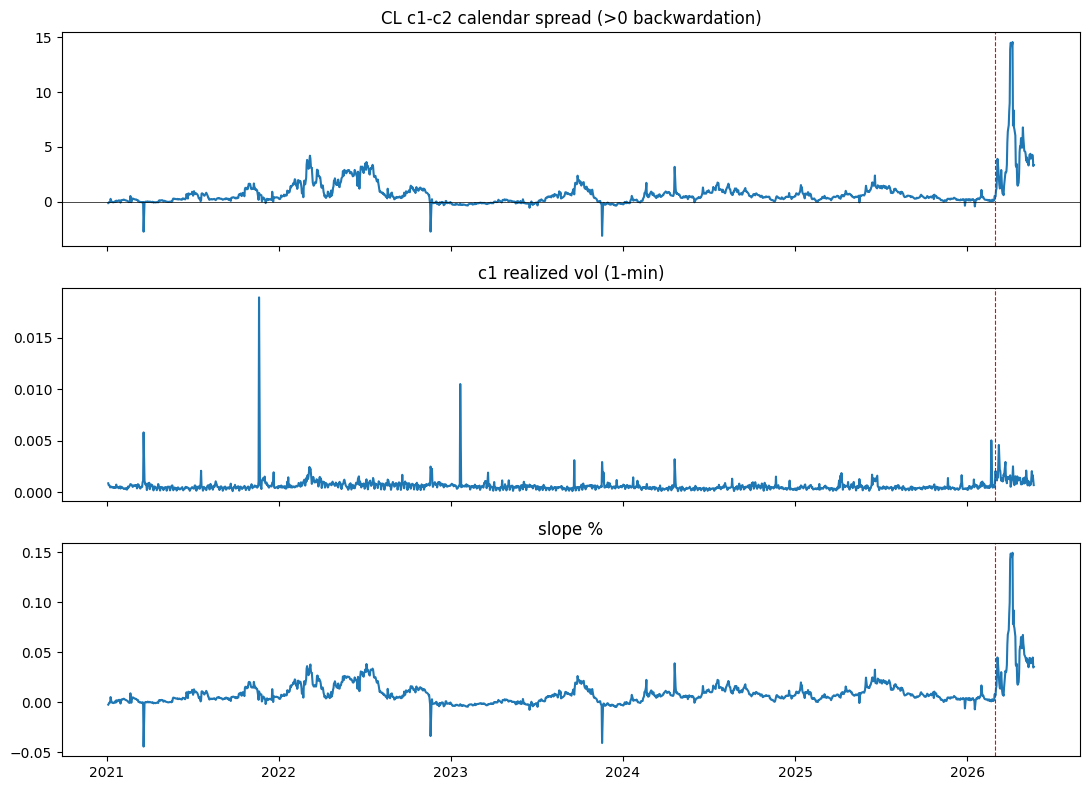

In [7]:
import matplotlib.pyplot as plt

assert panel.index.is_monotonic_increasing, "dates not sorted"
assert not panel.index.duplicated().any(), "duplicate dates"
print("rows:", len(panel), "| NaN in cal_1_2:", int(panel['cal_1_2'].isna().sum()))
print(panel[["c1","c2","cal_1_2","rv_c1","slope_pct","days_to_expiry"]].describe().round(3))

fig, ax = plt.subplots(3, 1, figsize=(11,8), sharex=True)
ax[0].plot(panel.index, panel["cal_1_2"]); ax[0].axhline(0, color="k", lw=.5)
ax[0].set_title("CL c1-c2 calendar spread (>0 backwardation)")
ax[1].plot(panel.index, panel["rv_c1"]); ax[1].set_title("c1 realized vol (1-min)")
ax[2].plot(panel.index, panel["cal_1_2"]/panel["c2"]); ax[2].set_title("slope %")
for a in ax: a.axvline(TEST_START, color="r", ls="--", lw=.8)
plt.tight_layout(); plt.show()